<a href="https://colab.research.google.com/github/manuellazarte/TP-Mineria-Datos-Pinguinos/blob/main/TP1_Lazarte_Larrubia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Práctico N°1 - Minería de Datos:

> **Año:** 2026  
> **Integrantes:**  
> * Larrubia, Agustín.  
> * Lazarte, Manuel.


## Introducción:
&emsp;El trabajo que se encuentra a continuación tiene como objetivo utilizar los conocimientos adquiridos en las Unidades 2 y 3 de la materia en el dataset 'penguins_size.csv' el cual contiene datos sobre distintas especies de pingüinos.

## Creación de ambiente e importación de dependencias:


In [ ]:
!pip install feature-engine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 6.2 MB/s eta 0:00:00


In [ ]:
# Manejo de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import plotly.express as px
import seaborn as sns

# Preparación de datos
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

## Adquisición y preparación de los datos:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

### Lectura:

In [ ]:
#file_path = 'penguins_size.csv' #Agus
file_path = '/content/drive/MyDrive/FCEIA/Minería de datos/TPs/TP1/penguins_size.csv' #Manu

df = pd.read_csv(file_path, sep=';')
display(df.head())

,Especie,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g),Sexo,Unnamed: 6,Unnamed: 7
0,Adelie Penguin,39.1,18.7,181.0,3750.0,MALE,NaN,NaN
1,Adelie Penguin,39.5,17.4,186.0,3800.0,FEMALE,NaN,NaN
2,Adelie Penguin,40.3,18.0,195.0,3250.0,FEMALE,NaN,NaN
3,Adelie Penguin,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Adelie Penguin,36.7,19.3,193.0,3450.0,FEMALE,NaN,NaN


### Analisis de la estructura de los datos:

&emsp;Realizamos el debido analisis de la estructura y contenido del dataset para ver detalles sobre su información general: cantidad de filas (muestras), nombre y tipo de dato de los atributos, cantidad de valores no nulos.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 347 entries, 0 to 346
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Especie                  347 non-null    object 
 1   Longitud Culmen (mm)     345 non-null    float64
 2   Profundidad Culmen (mm)  345 non-null    float64
 3   Longitud Aleta (mm)      345 non-null    float64
 4   Masa corporal (g)        345 non-null    float64
 5   Sexo                     337 non-null    object 
 6   Unnamed: 6               0 non-null      float64
 7   Unnamed: 7               0 non-null      float64
dtypes: float64(6), object(2)
memory usage: 21.8+ KB


### Limpieza de datos:

&emsp;Como se pudo observar en el paso anterior hay dos atributos \(columnas) que no cuentan con nombre y tampoco poseen contenido alguno \(0 non-null) por lo que procedemos a su eliminación, como tambien para todo registro \(fila) que no posea medidas aunque si tenga especificada la especie.

In [ ]:
df = df.dropna(axis=1, how='all')
df = df.dropna(subset=df.columns.drop('Especie'), how='all')
display(df.head())

,Especie,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g),Sexo
0,Adelie Penguin,39.1,18.7,181.0,3750.0,MALE
1,Adelie Penguin,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie Penguin,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie Penguin,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie Penguin,39.3,20.6,190.0,3650.0,MALE


&emsp;Luego de eliminar las columnas completamente vacías y las filas que no contienen información en ninguna de las variables más alla de la especie, se verifica nuevamente la estructura del dataset.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 345 entries, 0 to 346
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Especie                  345 non-null    object 
 1   Longitud Culmen (mm)     345 non-null    float64
 2   Profundidad Culmen (mm)  345 non-null    float64
 3   Longitud Aleta (mm)      345 non-null    float64
 4   Masa corporal (g)        345 non-null    float64
 5   Sexo                     337 non-null    object 
dtypes: float64(4), object(2)
memory usage: 18.9+ KB


### Normalización:

&emsp;Como se observa en la estructura de arriba tenemos variables que poseen distintas escalas como por ejemplo Longitud Culmen, Profundidad Culmen y Longitud aleta en milimetros contra Masa corporal que esta en gramos y ademas de escalas poseen distinto ordenes de magnitud, por lo que es necesario normalizar estas variables para hacer que todas contribuyan de forma equitativa al análisis, evitando que la Masa Corporal domine los resultados simplemente por tener valores numericos más grandes

In [ ]:
# Excluimos Especie y Sexo
xPenguins = df.drop(['Especie', 'Sexo'], axis=1)

# Almacenamos para colorear el grafico mas adelante
yEspeciePenguins = df['Especie']
ySexoPenguins = df['Sexo']

display(xPenguins)

,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g)
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
4,36.7,19.3,193.0,3450.0
5,39.3,20.6,190.0,3650.0
...,...,...,...,...
341,47.2,13.7,214.0,4925.0
343,46.8,14.3,215.0,4850.0
344,50.4,15.7,222.0,5750.0
345,45.2,14.8,212.0,5200.0


In [ ]:
xPenguinsScaled = StandardScaler().fit_transform(xPenguins)

## Análisis exploratorio

Observamos la correlación entre atributos

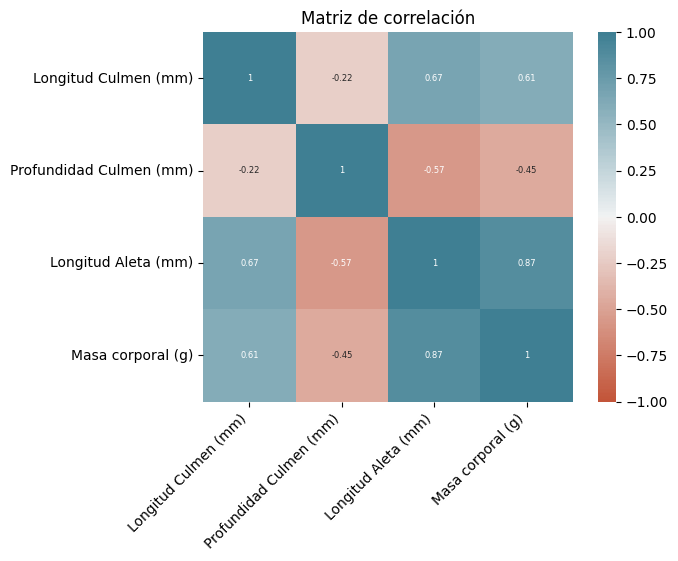

In [ ]:
numeric_X = X_train.select_dtypes(include=[np.number])
corr = numeric_X.corr()
ax = sns.heatmap(
    corr,
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True,
    annot = True,
    annot_kws = {'size': 6}
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    horizontalalignment='right'
)
plt.title('Matriz de correlación')
plt.show()

Se observa una correlación positiva fuerte entre `Longitud Aleta (mm)` y `Masa corporal (g)`, moderada entre `Longitud Culmen (mm)` - `Masa corporal (g)` y `Longitud culmen (mm)` - `Longitud Aleta (mm)`
Al mismo tiempo también se puede ver una correlación negativa moderada entre `Profundidad Culmen (mm)` - `Masa corporal (g)` y `Profundida Culmen (mm)` - `Longitud Aleta (mm)`

In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 276 entries, 24 to 219
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Longitud Culmen (mm)     276 non-null    float64
 1   Profundidad Culmen (mm)  276 non-null    float64
 2   Longitud Aleta (mm)      276 non-null    float64
 3   Masa corporal (g)        276 non-null    float64
 4   Sexo                     269 non-null    object 
dtypes: float64(4), object(1)
memory usage: 12.9+ KB


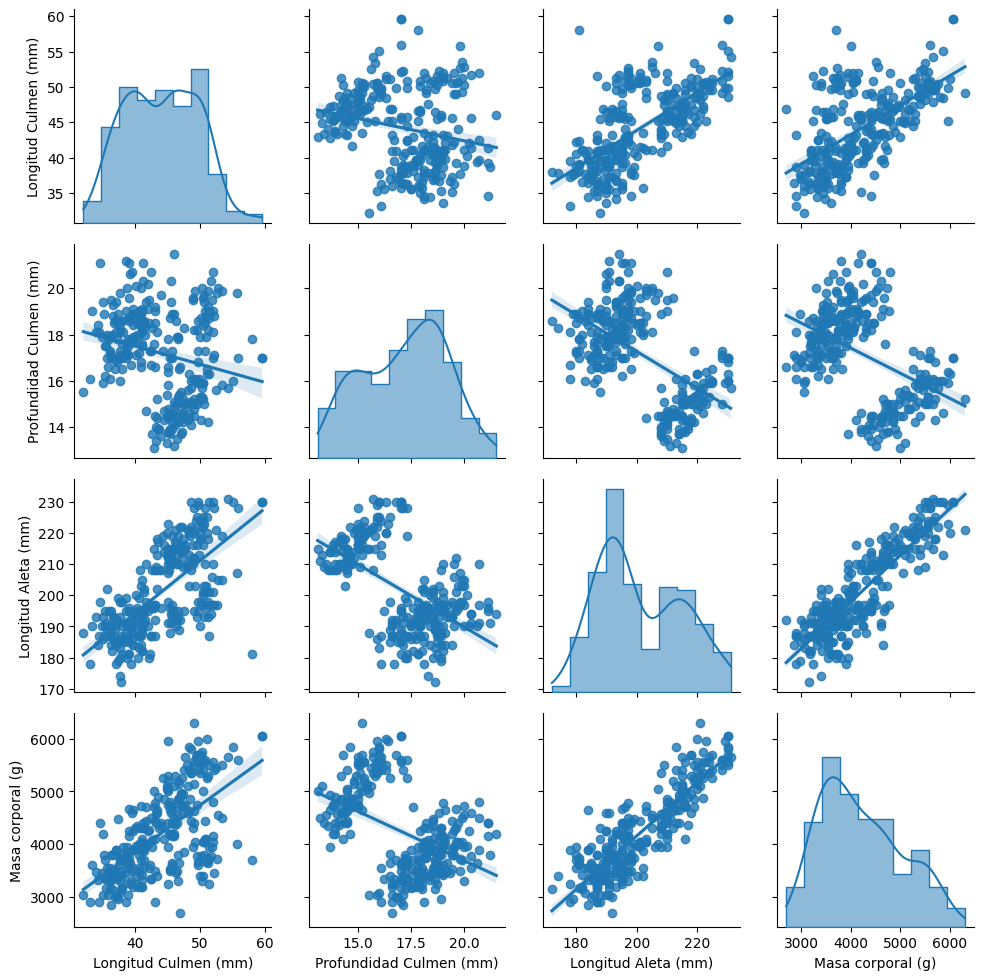

In [ ]:
subcols = ['Longitud Culmen (mm)', 'Profundidad Culmen (mm)','Longitud Aleta (mm)', 'Masa corporal (g)']
g = sns.PairGrid(X_train[subcols])
g.map_diag(sns.histplot, kde=True, element='step')
g.map_offdiag(sns.regplot)

En los scatterplots se observan relaciones positivas entre `Longitud Culmen (mm)`, `Longitud Aleta (mm)` y `Masa corporal (g)`, siendo especialmente marcada la relación entre `Longitud Aleta (mm)` y `Masa corporal (g)`. Por otro lado, `Profundidad Culmen (mm)` presenta relaciones negativas con las otras tres variables. En varias de estas relaciones se observan agrupamientos diferenciados de los datos, en lugar de una única distribución continua.

Así mismo, En la diagonal se observan las distribuciones individuales de las cuatro variables. `Longitud Culmen (mm)` presenta una distribución relativamente extendida, con cierta concentración de valores en dos zonas. `Profundidad Culmen (mm)` también muestra dos concentraciones diferenciadas. `Longitud Aleta (mm)` presenta una bimodalidad marcada, con un grupo de valores alrededor de 185–200 mm y otro cercano a 210–225 mm. `Masa corporal (g)` presenta asimismo una distribución bimodal, con una concentración en torno a 3000–4000 g y otra en valores superiores.

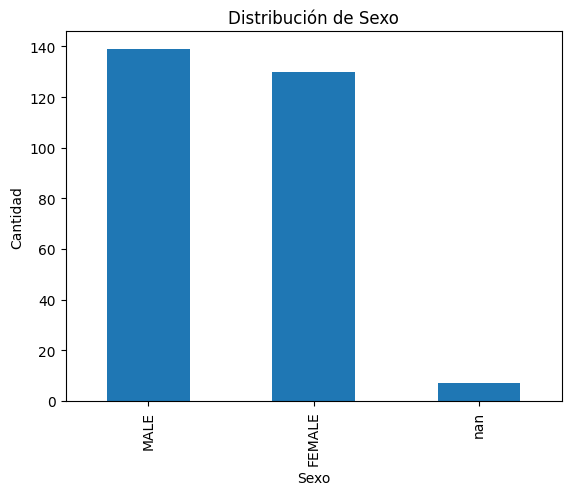

In [ ]:
X_train["Sexo"].value_counts(dropna=False).plot(kind="bar")

plt.xlabel("Sexo")
plt.ylabel("Cantidad")
plt.title("Distribución de Sexo")
plt.show()

In [ ]:
X_train["Sexo"].value_counts(dropna=False)

,count
Sexo,
MALE,139
FEMALE,130
NaN,7


Se observa una distribución relativamente equilibrada entre las categorías `MALE` y `FEMALE`, aunque existe una ligera mayor proporción de registros correspondientes a `MALE`. Además, se identificaron 7 valores faltantes

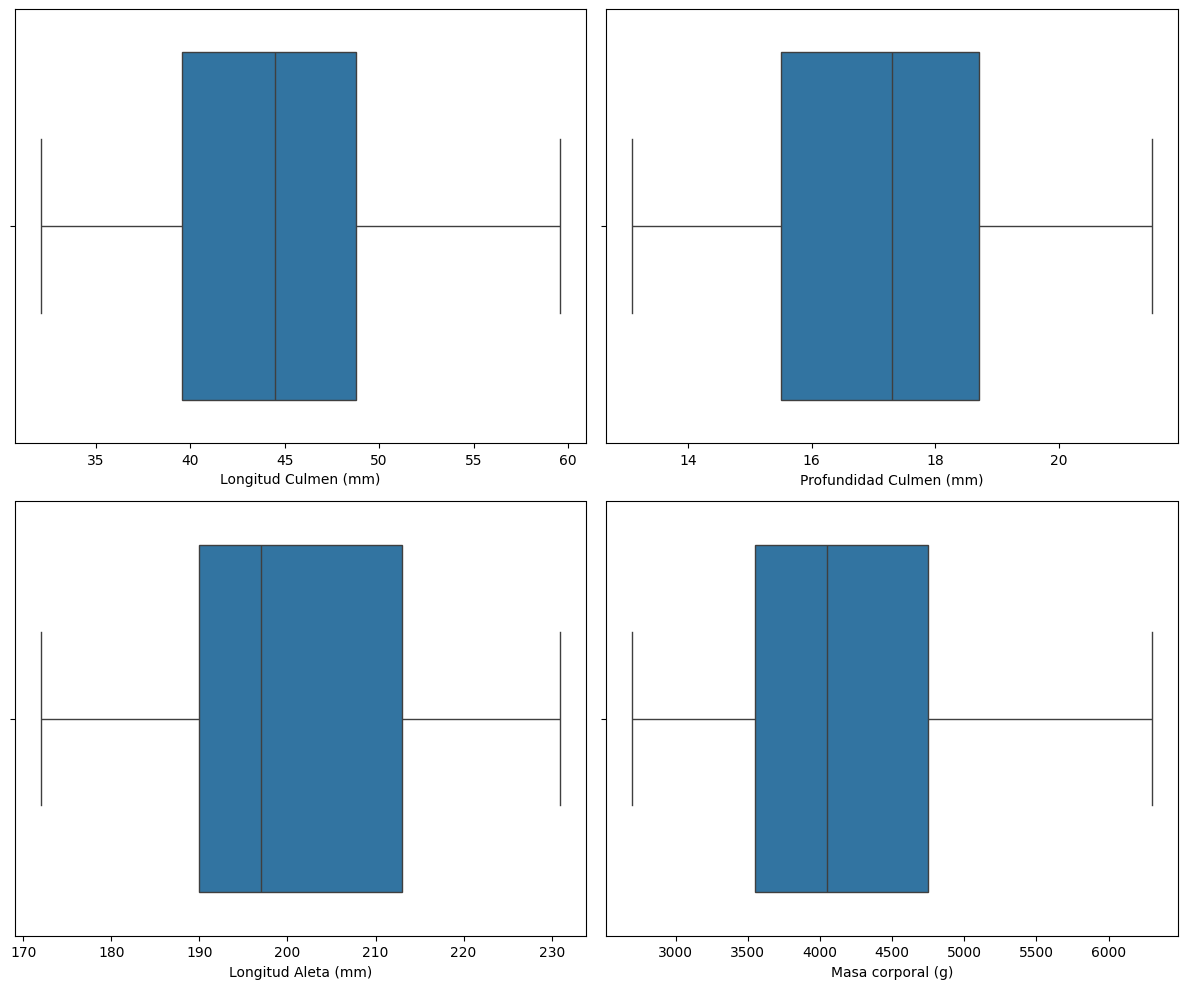

In [ ]:
cols = subcols
fig, axes = plt.subplots(nrows=2, ncols=2, sharey=False,
                         figsize=(12, 10))
for i, col in enumerate(cols, 1):
    sns.boxplot(data=X_train, x=col, ax=axes.flatten()[i-1])

plt.tight_layout()
plt.show()

A partir de los diagramas de caja no se identificaron valores extremos claramente aislados que requieran ser eliminados. Por lo tanto, se decidió conservar los registros originales.

En particular, `Longitud Aleta (mm)` presenta una distribución con cierto sesgo hacia la izquierda, mientras que las demás variables muestran distribuciones más concentradas.

## Imputación de datos

Se decidió imputar los valores faltantes de `Sexo` mediante la categoría más frecuente (moda), ya que se trata de una variable categórica nominal. Este método permite completar los valores faltantes utilizando únicamente información disponible en el conjunto de entrenamiento.

In [ ]:
imputer = SimpleImputer(strategy="most_frequent")
X_train[["Sexo"]] = imputer.fit_transform(X_train[["Sexo"]])
X_test[["Sexo"]] = imputer.transform(X_test[["Sexo"]])

In [ ]:
X_train["Sexo"].value_counts(dropna=False)

,count
Sexo,
MALE,146
FEMALE,130


Se optó por una codificación binaria, asignando 0 a FEMALE y 1 a MALE, ya que la variable posee únicamente dos categorías.

In [ ]:
sexo_mapping = {
    "FEMALE": 0,
    "MALE": 1
}

X_train["Sexo"] = X_train["Sexo"].map(sexo_mapping)
X_test["Sexo"] = X_test["Sexo"].map(sexo_mapping)

In [ ]:
display(X_train.head())
display(X_train["Sexo"].value_counts())

,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g),Sexo
24,38.8,17.2,180.0,3800.0,1
135,38.1,17.6,187.0,3425.0,0
35,39.2,21.1,196.0,4150.0,1
248,44.5,14.3,216.0,4100.0,1
346,49.9,16.1,213.0,5400.0,1


,count
Sexo,
1,146
0,130


## Estandarizado

Utilizaremos StandardScaler para estandarizar las variables numéricas, debido a que presentan diferentes escalas y unidades de medida. Los parámetros de estandarización serán calculados sobre el conjunto de entrenamiento y posteriormente aplicados al conjunto de test.

La variable Sexo no se estandariza, ya que luego de su codificación representa directamente una categoría binaria. La estandarización se aplica únicamente a las variables numéricas continuas, cuyos valores presentan diferentes escalas y unidades de medida.

Finalmente, se incorporó la variable `Sexo` ya codificada al conjunto de variables numéricas estandarizadas, obteniendo X_train_final y X_test_final.

In [ ]:
scaler = StandardScaler().set_output(transform="pandas")

X_train_std = scaler.fit_transform(X_train[subcols])
X_test_std = scaler.transform(X_test[subcols])

X_train_std.describe()

,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g)
count,2.760000e+02,2.760000e+02,2.760000e+02,2.760000e+02
mean,1.451335e-15,-1.287215e-16,-5.374123e-16,-4.440892e-16
std,1.001817e+00,1.001817e+00,1.001817e+00,1.001817e+00
min,-2.157752e+00,-2.076606e+00,-2.077454e+00,-1.862676e+00
25%,-8.178999e-01,-8.555285e-01,-7.932943e-01,-8.179475e-01
50%,6.487867e-02,6.027964e-02,-2.938989e-01,-2.034014e-01
75%,8.311484e-01,7.725749e-01,8.475764e-01,6.569632e-01
max,2.771469e+00,2.197165e+00,2.131736e+00,2.562056e+00


In [ ]:
print("Valores faltantes:")
display(X_train_std.isna().sum())

print("Dimensiones:")
print("X_train:", X_train_std.shape)
print("X_test:", X_test_std.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Valores faltantes:


,0
Longitud Culmen (mm),0
Profundidad Culmen (mm),0
Longitud Aleta (mm),0
Masa corporal (g),0


Dimensiones:
X_train: (276, 4)
X_test: (69, 4)
y_train: (276,)
y_test: (69,)


La estadística descriptivapermite verificar que la transformación se realizó correctamente. Las cuatro variables numéricas presentan una media prácticamente igual a 0 y una desviación estándar aproximadamente igual a 1.

La estandarización fue calculada utilizando únicamente el conjunto de entrenamiento y posteriormente aplicada al conjunto de test, evitando incorporar información del conjunto de prueba durante la preparación de los datos.


In [ ]:
X_train_final = X_train_std.copy()
X_test_final = X_test_std.copy()

X_train_final["Sexo"] = X_train["Sexo"]
X_test_final["Sexo"] = X_test["Sexo"]

,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g),Sexo
24,-0.956814,0.009401,-1.506716,-0.510674,1
135,-1.082285,0.212914,-1.007321,-0.971584,0
35,-0.885117,1.993652,-0.365241,-0.080492,1
248,0.064879,-1.466067,1.061603,-0.141947,1
346,1.032798,-0.550259,0.847576,1.455873,1
...,...,...,...,...,...
105,-0.795494,0.874331,-1.221348,-0.817948,1
262,0.817705,-0.753772,0.490865,1.394419,1
46,-0.544552,0.925210,-1.364032,-0.971584,1
116,-0.992663,-0.092355,-0.935979,-1.616858,0


In [ ]:
print("Valores faltantes:")
display(X_train_final.isna().sum())

print("Dimensiones:")
print("X_train:", X_train_final.shape)
print("X_test:", X_test_final.shape)

Valores faltantes:


,0
Longitud Culmen (mm),0
Profundidad Culmen (mm),0
Longitud Aleta (mm),0
Masa corporal (g),0
Sexo,0


Dimensiones:
X_train: (276, 5)
X_test: (69, 5)


In [ ]:
from scipy.stats import chi2

def mahalanobis_d2(X):
    diff = X - X.mean(axis=0)
    cov_inv = np.linalg.inv(np.cov(X, rowvar=False))
    return np.einsum('ij,jk,ik->i', diff, cov_inv, diff)

umbral = chi2.ppf(0.999, df=len(subcols))  # 4 grados de libertad

d2 = pd.Series(index=X_train_std.index, dtype=float)
for esp in y_train.unique():
    idx = y_train[y_train == esp].index
    d2[idx] = mahalanobis_d2(X_train_std.loc[idx].values)

outliers = d2[d2 > umbral]
print(f"Umbral D²: {umbral:.2f} | Outliers detectados: {len(outliers)}")
display(X_train.loc[outliers.index].join(y_train))

Umbral D²: 18.47 | Outliers detectados: 1


,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g),Sexo,Especie
170,58.0,17.8,181.0,3700.0,0,Chinstrap penguin


In [ ]:
from scipy.stats import chi2

def mahalanobis_d2(X):
    diff = X - X.mean(axis=0)
    cov = np.cov(X, rowvar=False)
    cov_inv = np.linalg.inv(cov)

    return np.einsum('ij,jk,ik->i', diff, cov_inv, diff)


alpha = 0.01
umbral = chi2.ppf(1 - alpha, df=len(subcols))

d2 = pd.Series(index=X_train.index, dtype=float)

for especie in y_train.unique():
    idx = y_train[y_train == especie].index

    X_especie = X_train.loc[idx, subcols]

    d2.loc[idx] = mahalanobis_d2(X_especie.values)


outliers = d2[d2 > umbral]

print(f"Umbral D²: {umbral:.2f}")
print(f"Posibles outliers detectados: {len(outliers)}")

display(
    X_train.loc[outliers.index, subcols]
    .join(y_train.rename("Especie"))
    .assign(Distancia_Mahalanobis2=outliers)
)

Umbral D²: 13.28
Posibles outliers detectados: 3


,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g),Especie,Distancia_Mahalanobis2
260,44.4,17.3,219.0,5250.0,Gentoo penguin,17.002510
170,58.0,17.8,181.0,3700.0,Chinstrap penguin,22.418652
14,34.6,21.1,198.0,4400.0,Adelie Penguin,15.446369
